In [6]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "IDRiD"
    / "B. Disease Grading"
)

TRAIN_IMAGE_DIR = DATA_DIR / "1. Original Images" / "a. Training Set"
TEST_IMAGE_DIR = DATA_DIR / "1. Original Images" / "b. Testing Set"

GROUNDTRUTH_DIR = DATA_DIR / "2. Groundtruths"

print("Train images:", TRAIN_IMAGE_DIR)
print("Test images:", TEST_IMAGE_DIR)
print("Groundtruth:", GROUNDTRUTH_DIR)

Train images: /home/deepak/projects/aiml_biodata/data/raw/IDRiD/B. Disease Grading/1. Original Images/a. Training Set
Test images: /home/deepak/projects/aiml_biodata/data/raw/IDRiD/B. Disease Grading/1. Original Images/b. Testing Set
Groundtruth: /home/deepak/projects/aiml_biodata/data/raw/IDRiD/B. Disease Grading/2. Groundtruths


In [8]:
train_images = sorted(TRAIN_IMAGE_DIR.glob("*.jpg"))
test_images = sorted(TEST_IMAGE_DIR.glob("*.jpg"))

print("Training images:", len(train_images))
print("Testing images:", len(test_images))
print("Total images:", len(train_images) + len(test_images))

print("\nFirst 5 training images:")
for path in train_images[:5]:
    print(path.name)

print("\nFirst 5 testing images:")
for path in test_images[:5]:
    print(path.name)

Training images: 413
Testing images: 103
Total images: 516

First 5 training images:
IDRiD_001.jpg
IDRiD_002.jpg
IDRiD_003.jpg
IDRiD_004.jpg
IDRiD_005.jpg

First 5 testing images:
IDRiD_001.jpg
IDRiD_002.jpg
IDRiD_003.jpg
IDRiD_004.jpg
IDRiD_005.jpg


In [9]:
image_path = train_images[0]

# Read image using OpenCV
image_bgr = cv2.imread(str(image_path))

if image_bgr is None:
    raise ValueError(f"Could not read image: {image_path}")

# Convert BGR → RGB for matplotlib
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

print("Image:", image_path.name)
print("Shape:", image_rgb.shape)
print("Data type:", image_rgb.dtype)
print("Min pixel value:", image_rgb.min())
print("Max pixel value:", image_rgb.max())

Image: IDRiD_001.jpg
Shape: (2848, 4288, 3)
Data type: uint8
Min pixel value: 0
Max pixel value: 255


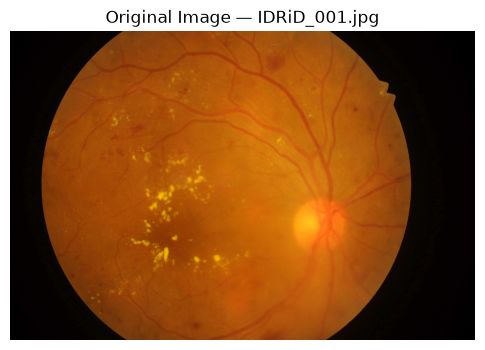

In [14]:
plt.figure(figsize=(6,6))

plt.imshow(image_rgb)
plt.title(f"Original Image — {image_path.name}")
plt.axis("off")

plt.show()

## Resize to 512 x 512

In [12]:
TARGET_SIZE = (512, 512)

resized_rgb = cv2.resize(
    image_rgb,
    TARGET_SIZE,
    interpolation=cv2.INTER_AREA
)

print("Original shape:", image_rgb.shape)
print("Resized shape:", resized_rgb.shape)

Original shape: (2848, 4288, 3)
Resized shape: (512, 512, 3)


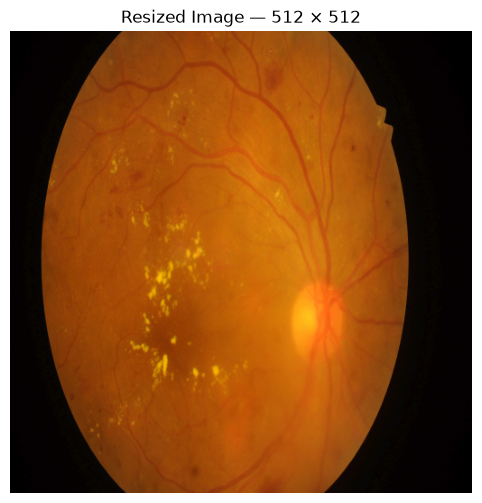

In [15]:
plt.figure(figsize=(6,6))

plt.imshow(resized_rgb)
plt.title("Resized Image — 512 × 512")
plt.axis("off")

plt.show()

## Create the retinal-region mask

In [16]:
# Convert RGB image to grayscale
gray = cv2.cvtColor(resized_rgb, cv2.COLOR_RGB2GRAY)

# Detect non-black retinal region
_, retinal_mask = cv2.threshold(
    gray,
    10,
    255,
    cv2.THRESH_BINARY
)

print("Mask shape:", retinal_mask.shape)
print("Unique values:", np.unique(retinal_mask))

Mask shape: (512, 512)
Unique values: [  0 255]


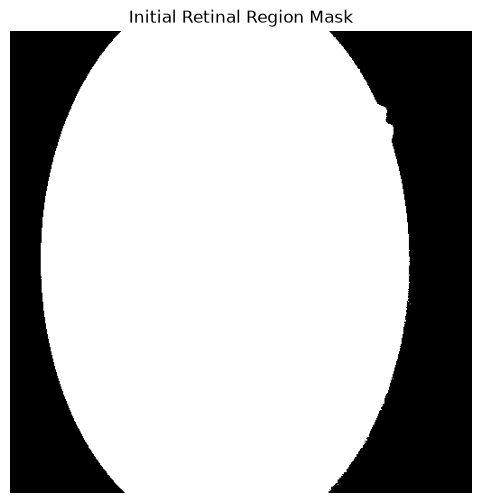

In [18]:
plt.figure(figsize=(6,6))

plt.imshow(retinal_mask, cmap="gray")
plt.title("Initial Retinal Region Mask")
plt.axis("off")

plt.show()

## Clean the mask using morphology

In [19]:
kernel = np.ones((5, 5), np.uint8)

retinal_mask = cv2.morphologyEx(
    retinal_mask,
    cv2.MORPH_CLOSE,
    kernel
)

retinal_mask = cv2.morphologyEx(
    retinal_mask,
    cv2.MORPH_OPEN,
    kernel
)

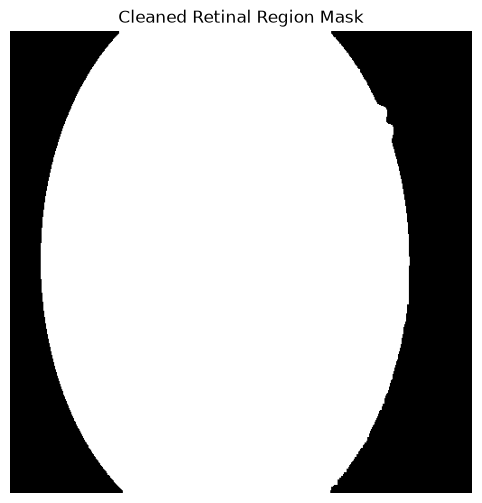

In [21]:
plt.figure(figsize=(6,6))

plt.imshow(retinal_mask, cmap="gray")
plt.title("Cleaned Retinal Region Mask")
plt.axis("off")

plt.show()

### Retinal Mask Cleaning

After creating the initial retinal mask, morphological operations are used to clean it:

- **Morphological closing** fills small gaps and holes inside the retinal region.
- **Morphological opening** removes small unwanted noise and isolated regions.

This produces a cleaner binary mask containing the retinal area while excluding most of the surrounding background.

In [22]:
masked_rgb = cv2.bitwise_and(
    resized_rgb,
    resized_rgb,
    mask=retinal_mask
)

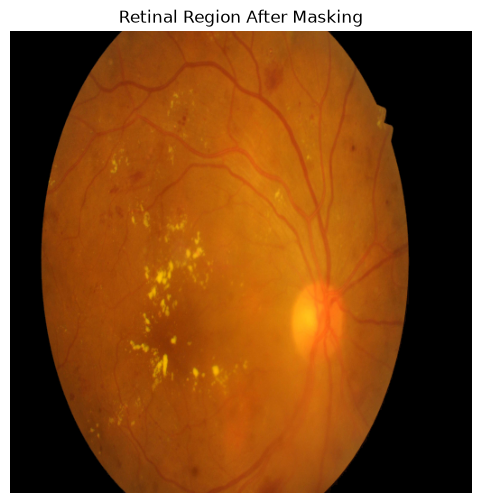

In [24]:
plt.figure(figsize=(6,6))

plt.imshow(masked_rgb)
plt.title("Retinal Region After Masking")
plt.axis("off")

plt.show()

## Extract the green channel

In [25]:
green_channel = masked_rgb[:, :, 1]

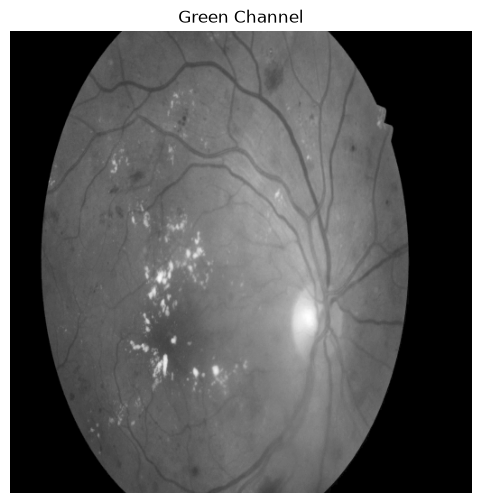

In [26]:
plt.figure(figsize=(6, 6))

plt.imshow(green_channel, cmap="gray")
plt.title("Green Channel")
plt.axis("off")

plt.show()

## apply CLAHE

In [27]:
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

green_enhanced = clahe.apply(green_channel)

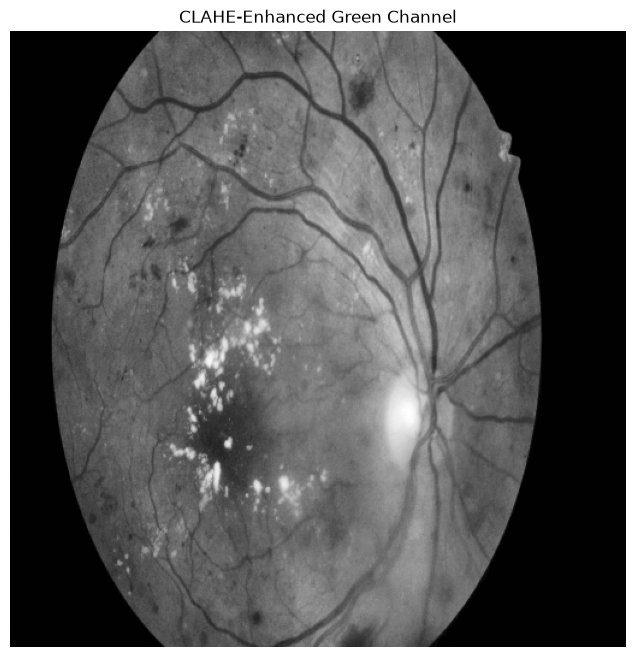

In [28]:
plt.figure(figsize=(8, 8))

plt.imshow(green_enhanced, cmap="gray")
plt.title("CLAHE-Enhanced Green Channel")
plt.axis("off")

plt.show()